In [13]:
import warnings
warnings.filterwarnings('ignore')

# Q1

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_mall = pd.read_csv("Mall_Customers.csv")

encoder = LabelEncoder()
df_mall["Gender"] = encoder.fit_transform(df_mall["Gender"])

df_mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [15]:
features_df = df_mall.drop(columns=['CustomerID'])

kmeans_unscaled = KMeans(n_clusters=5, init="k-means++", random_state=73, n_init=10)
df_mall['Cluster_Unscaled'] = kmeans_unscaled.fit_predict(features_df)

scaler = StandardScaler()
features_scaled = features_df.copy()

cols_to_scale = ['Gender', 'Annual Income (k$)', 'Spending Score (1-100)']
features_scaled[cols_to_scale] = scaler.fit_transform(features_df[cols_to_scale])

kmeans_scaled = KMeans(n_clusters=5, init="k-means++", random_state=73, n_init=10)
df_mall['Cluster_Scaled'] = kmeans_scaled.fit_predict(features_scaled)

print("Mean values for UNSCALED Clusters")
print(df_mall.groupby('Cluster_Unscaled')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean())

print("\n Mean values for SCALED (except Age) Clusters ")
print(df_mall.groupby('Cluster_Scaled')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean())

Mean values for UNSCALED Clusters
                        Age  Annual Income (k$)  Spending Score (1-100)
Cluster_Unscaled                                                       
0                 45.217391           26.304348               20.913043
1                 43.088608           55.291139               49.569620
2                 32.692308           86.538462               82.128205
3                 40.666667           87.750000               17.583333
4                 25.521739           26.304348               78.565217

 Mean values for SCALED (except Age) Clusters 
                      Age  Annual Income (k$)  Spending Score (1-100)
Cluster_Scaled                                                       
0               30.000000           71.173913               67.304348
1               63.535714           52.785714               38.500000
2               49.186047           59.860465               35.651163
3               21.157895           45.684211               54.9

# Q2

In [16]:
fleet_data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [152000, 118000, 255000, 82000, 105000, 215000, 185000, 305000, 72000, 285000],
    'fuel_efficiency': [14, 19, 11, 21, 19, 13, 15, 7, 25, 10],
    'maintenance_cost': [5100, 4200, 7100, 2100, 2900, 6400, 5600, 8200, 1600, 7400],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df_fleet = pd.DataFrame(fleet_data)

le_fleet = LabelEncoder()
df_fleet["vehicle_type_encoded"] = le_fleet.fit_transform(df_fleet["vehicle_type"])

fleet_features = ['mileage', 'fuel_efficiency', 'maintenance_cost', 'vehicle_type_encoded']
X_fleet = df_fleet[fleet_features]

In [17]:
kmeans_raw = KMeans(n_clusters=3, random_state=101, n_init=10)
df_fleet['cluster_unscaled'] = kmeans_raw.fit_predict(X_fleet)

scaler_fleet = StandardScaler()
X_fleet_scaled = X_fleet.copy()
numeric_cols = ['mileage', 'fuel_efficiency', 'maintenance_cost']
X_fleet_scaled[numeric_cols] = scaler_fleet.fit_transform(X_fleet[numeric_cols])

kmeans_std = KMeans(n_clusters=3, random_state=101, n_init=10)
df_fleet["cluster_scaled"] = kmeans_std.fit_predict(X_fleet_scaled)

df_fleet[['vehicle_type', 'mileage', 'maintenance_cost', 'cluster_unscaled', 'cluster_scaled']]

,vehicle_type,mileage,maintenance_cost,cluster_unscaled,cluster_scaled
0,SUV,152000,5100,1,2
1,Sedan,118000,4200,2,2
2,Truck,255000,7100,0,0
3,Hatchback,82000,2100,2,1
4,Sedan,105000,2900,2,2
5,Truck,215000,6400,1,0
6,SUV,185000,5600,1,2
7,Truck,305000,8200,0,0
8,Hatchback,72000,1600,2,1
9,SUV,285000,7400,0,0


# Q3

In [18]:
student_data = {
    'student_id': range(201, 221), # IDs 201 to 220
    'GPA': [3.7, 2.2, 3.6, 2.7, 1.8, 3.8, 2.5, 3.3, 3.6, 2.1, 
            3.1, 3.5, 2.3, 3.0, 1.6, 3.9, 2.7, 3.5, 1.9, 2.8],
    'study_hours': [24, 6, 21, 11, 5, 29, 9, 16, 23, 7, 
                    15, 17, 8, 15, 4, 27, 11, 20, 6, 12],
    'attendance_rate': [94, 62, 91, 74, 52, 97, 66, 86, 93, 58, 
                        81, 89, 64, 77, 42, 95, 71, 90, 48, 82]
}

df_students = pd.DataFrame(student_data)
features_students = df_students[['GPA', 'study_hours', 'attendance_rate']]

std_scaler = StandardScaler()
X_students_scaled = std_scaler.fit_transform(features_students)

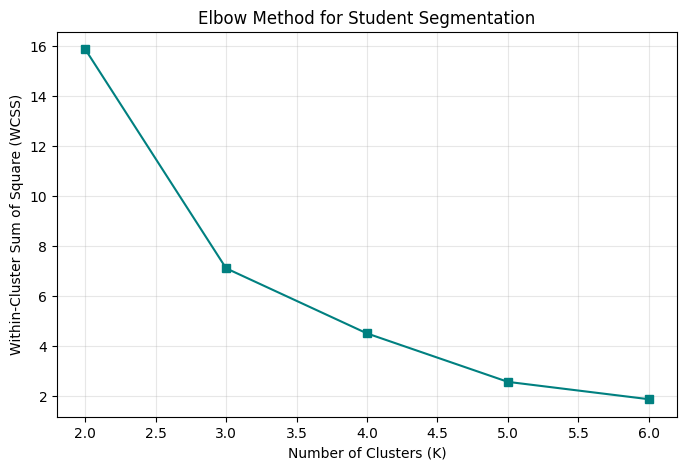

In [19]:
wcss_list = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    km.fit(X_students_scaled)
    wcss_list.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 7), wcss_list, marker='s', linestyle='-', color='teal')
plt.title('Elbow Method for Student Segmentation')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Square (WCSS)')
plt.grid(True, alpha=0.3)
plt.show()

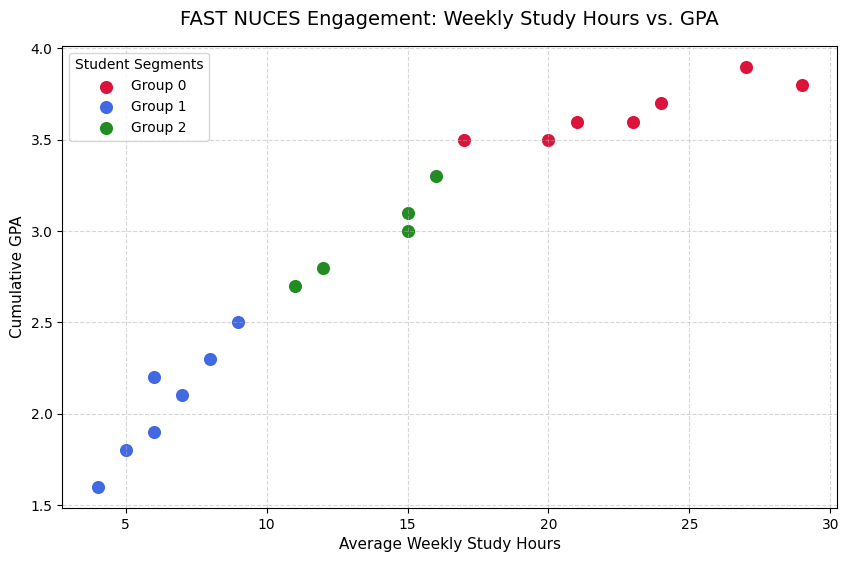

    student_id  Cluster
0          201        0
1          202        1
2          203        0
3          204        2
4          205        1
5          206        0
6          207        1
7          208        2
8          209        0
9          210        1
10         211        2
11         212        0
12         213        1
13         214        2
14         215        1
15         216        0
16         217        2
17         218        0
18         219        1
19         220        2


In [20]:
final_kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
df_students['Cluster'] = final_kmeans.fit_predict(X_students_scaled)
plt.figure(figsize=(10, 6))

cluster_colors = {0: 'crimson', 1: 'royalblue', 2: 'forestgreen'}

for cluster_id in range(3):
    subset = df_students[df_students['Cluster'] == cluster_id]
    plt.scatter(subset['study_hours'], subset['GPA'], 
                s=120, 
                c=cluster_colors[cluster_id], 
                label=f'Group {cluster_id}', 
                edgecolors='white', 
                linewidth=1.5)

plt.title('FAST NUCES Engagement: Weekly Study Hours vs. GPA', fontsize=14, pad=15)
plt.xlabel('Average Weekly Study Hours', fontsize=11)
plt.ylabel('Cumulative GPA', fontsize=11)
plt.legend(title="Student Segments")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(df_students[['student_id', 'Cluster']])